# Deep Learning from Scratch: MLP & CNN on MNIST

**University of Oxford — AI Tutorial**

This notebook implements two deep learning classifiers entirely from scratch using only NumPy:

1. **Feed-Forward Neural Network (MLP)** — 1-layer and 2-layer variants
2. **Convolutional Neural Network (CNN)** — conv layer, ReLU, max pooling, dense output

**Dataset:** MNIST — 70,000 grayscale images (28×28) of handwritten digits 0–9  
**Goal:** Achieve performance close to state-of-the-art for each method  
**Key concepts:** ReLU, Softmax, Cross-Entropy, Backpropagation, Convolution, Max Pooling

---

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import time

np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 2. Load & Explore MNIST

In [2]:
from tensorflow.keras.datasets import mnist

(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print(f'Training set: {X_train_raw.shape}  — {X_train_raw.shape[0]} images, {X_train_raw.shape[1]}x{X_train_raw.shape[2]} pixels')
print(f'Test set:     {X_test_raw.shape}  — {X_test_raw.shape[0]} images, {X_test_raw.shape[1]}x{X_test_raw.shape[2]} pixels')
print(f'Labels:       {np.unique(y_train)} (digits 0-9)')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28)  — 60000 images, 28x28 pixels
Test set:     (10000, 28, 28)  — 10000 images, 28x28 pixels
Labels:       [0 1 2 3 4 5 6 7 8 9] (digits 0-9)


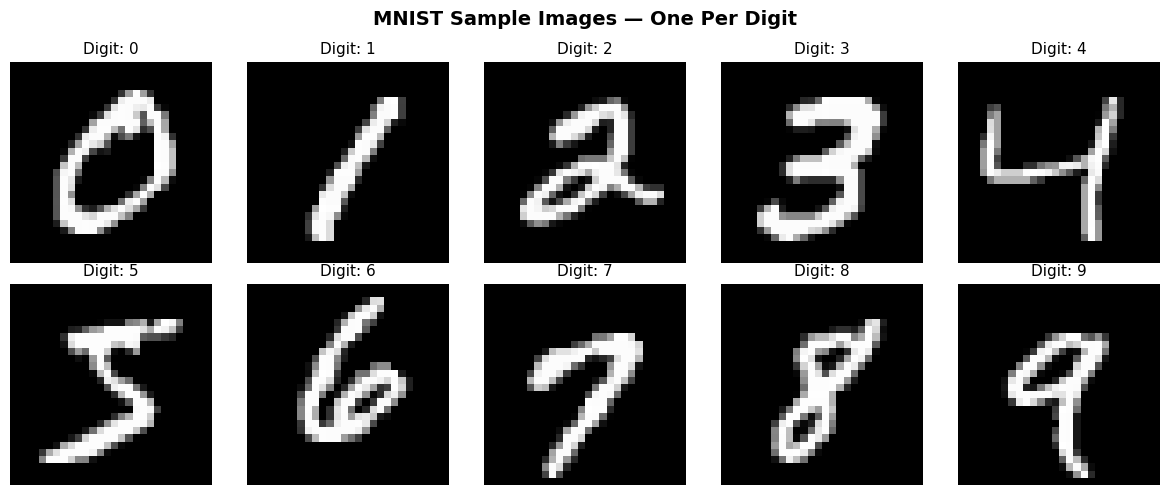

In [3]:
# Show one example per digit
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('MNIST Sample Images — One Per Digit', fontsize=14, fontweight='bold')

for digit, ax in enumerate(axes.flat):
    idx = np.where(y_train == digit)[0][0]
    ax.imshow(X_train_raw[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Preprocess Data

We prepare two versions:
- **Flat** (784,) — for the MLP
- **2D** (1, 28, 28) — for the CNN (channels-first format)

In [4]:
# MLP data: flatten 28x28 → 784, normalize 0–255 → 0–1
X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1) / 255.0
X_test_flat  = X_test_raw.reshape(X_test_raw.shape[0], -1)  / 255.0

# CNN data: add channel dimension → (N, 1, 28, 28), normalize
X_train_cnn = X_train_raw[:, np.newaxis, :, :] / 255.0
X_test_cnn  = X_test_raw[:, np.newaxis, :, :]  / 255.0

print(f'MLP input shape: {X_train_flat.shape}')  # (60000, 784)
print(f'CNN input shape: {X_train_cnn.shape}')   # (60000, 1, 28, 28)

MLP input shape: (60000, 784)
CNN input shape: (60000, 1, 28, 28)


---
# Part 1: Feed-Forward Neural Network (MLP)

**Architecture:** Input(784) → Hidden Layer(s) → Output(10)  
**Activation:** ReLU (hidden), Softmax (output)  
**Training:** Mini-batch gradient descent + backpropagation

## 4. MLP Implementation

In [5]:
class MLP:
    """
    Flexible Multi-Layer Perceptron — 1 or 2 hidden layers.
    Built entirely from scratch using NumPy.

    Forward pass:  X → Z1 → A1 (ReLU) → [Z2 → A2 (ReLU) →] Zout → Softmax
    Backward pass: Chain rule through every layer manually.
    """

    def __init__(self, layer_sizes, lr=0.1):
        """
        Args:
            layer_sizes: e.g. [784, 256, 10]       → 1 hidden layer
                              [784, 256, 128, 10]  → 2 hidden layers
            lr: learning rate
        """
        self.lr = lr
        self.num_layers = len(layer_sizes) - 1
        self.weights = []
        self.biases  = []

        # He initialization — optimal for ReLU activations
        for i in range(self.num_layers):
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

    # ── Activations ──────────────────────────────────────────────────────────

    def relu(self, z):
        return np.maximum(0, z)

    def relu_grad(self, z):
        return (z > 0).astype(float)

    def softmax(self, z):
        # Subtract row max for numerical stability
        e = np.exp(z - np.max(z, axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    # ── Forward pass ─────────────────────────────────────────────────────────

    def forward(self, X):
        self.zs  = []
        self.acts = [X]
        a = X
        for i in range(self.num_layers):
            z = a @ self.weights[i] + self.biases[i]
            self.zs.append(z)
            a = self.relu(z) if i < self.num_layers - 1 else self.softmax(z)
            self.acts.append(a)
        return self.acts[-1]

    # ── Loss ─────────────────────────────────────────────────────────────────

    def loss(self, y_pred, y_true):
        n = len(y_true)
        return -np.mean(np.log(y_pred[np.arange(n), y_true] + 1e-8))

    # ── Backward pass ────────────────────────────────────────────────────────

    def backward(self, X, y_true):
        n = X.shape[0]
        # Output gradient (softmax + cross-entropy combined derivative)
        delta = self.acts[-1].copy()
        delta[np.arange(n), y_true] -= 1
        delta /= n

        for i in reversed(range(self.num_layers)):
            dW = self.acts[i].T @ delta
            db = delta.sum(axis=0, keepdims=True)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.relu_grad(self.zs[i-1])
            self.weights[i] -= self.lr * dW
            self.biases[i]  -= self.lr * db

    # ── Predict & Accuracy ───────────────────────────────────────────────────

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)


print('MLP class ready.')

MLP class ready.


## 5. Train MLP

In [6]:
def train_mlp(model, X_train, y_train, X_test, y_test,
              epochs=30, batch_size=256, log_every=5):
    history = {'loss': [], 'train_acc': [], 'test_acc': []}
    n = len(X_train)
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        idx = np.random.permutation(n)
        X_s, y_s = X_train[idx], y_train[idx]

        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            model.forward(Xb)
            model.backward(Xb, yb)

        yp = model.forward(X_train)
        l  = model.loss(yp, y_train)
        ta = model.accuracy(X_train, y_train)
        va = model.accuracy(X_test,  y_test)

        history['loss'].append(l)
        history['train_acc'].append(ta)
        history['test_acc'].append(va)

        if epoch % log_every == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | Loss: {l:.4f} | '
                  f'Train: {ta:.2%} | Test: {va:.2%} | '
                  f'Time: {time.time()-t0:.1f}s')

    return history

In [7]:
print('=== 1-Layer MLP: 784 → 256 → 10 ===')
mlp1 = MLP([784, 256, 10], lr=0.1)
hist_mlp1 = train_mlp(mlp1, X_train_flat, y_train, X_test_flat, y_test, epochs=30)
print(f'\n✓ 1-Layer MLP Test Accuracy: {mlp1.accuracy(X_test_flat, y_test):.2%}')

=== 1-Layer MLP: 784 → 256 → 10 ===
Epoch   1/30 | Loss: 0.3400 | Train: 90.60% | Test: 90.92% | Time: 9.0s
Epoch   5/30 | Loss: 0.1938 | Train: 94.60% | Test: 94.46% | Time: 31.8s
Epoch  10/30 | Loss: 0.1284 | Train: 96.43% | Test: 96.07% | Time: 58.7s
Epoch  15/30 | Loss: 0.0966 | Train: 97.37% | Test: 96.85% | Time: 85.6s
Epoch  20/30 | Loss: 0.0777 | Train: 97.89% | Test: 97.24% | Time: 112.3s
Epoch  25/30 | Loss: 0.0635 | Train: 98.32% | Test: 97.49% | Time: 138.5s
Epoch  30/30 | Loss: 0.0540 | Train: 98.61% | Test: 97.71% | Time: 164.1s

✓ 1-Layer MLP Test Accuracy: 97.71%


In [8]:
print('=== 2-Layer MLP: 784 → 256 → 128 → 10 ===')
mlp2 = MLP([784, 256, 128, 10], lr=0.1)
hist_mlp2 = train_mlp(mlp2, X_train_flat, y_train, X_test_flat, y_test, epochs=30)
print(f'\n✓ 2-Layer MLP Test Accuracy: {mlp2.accuracy(X_test_flat, y_test):.2%}')

=== 2-Layer MLP: 784 → 256 → 128 → 10 ===
Epoch   1/30 | Loss: 0.3413 | Train: 89.12% | Test: 89.61% | Time: 7.8s
Epoch   5/30 | Loss: 0.1320 | Train: 96.28% | Test: 95.72% | Time: 34.8s
Epoch  10/30 | Loss: 0.0726 | Train: 98.00% | Test: 97.14% | Time: 67.9s
Epoch  15/30 | Loss: 0.0567 | Train: 98.35% | Test: 97.11% | Time: 103.2s
Epoch  20/30 | Loss: 0.0332 | Train: 99.18% | Test: 97.63% | Time: 135.6s
Epoch  25/30 | Loss: 0.0316 | Train: 99.12% | Test: 97.44% | Time: 166.6s
Epoch  30/30 | Loss: 0.0191 | Train: 99.61% | Test: 97.82% | Time: 202.5s

✓ 2-Layer MLP Test Accuracy: 97.82%


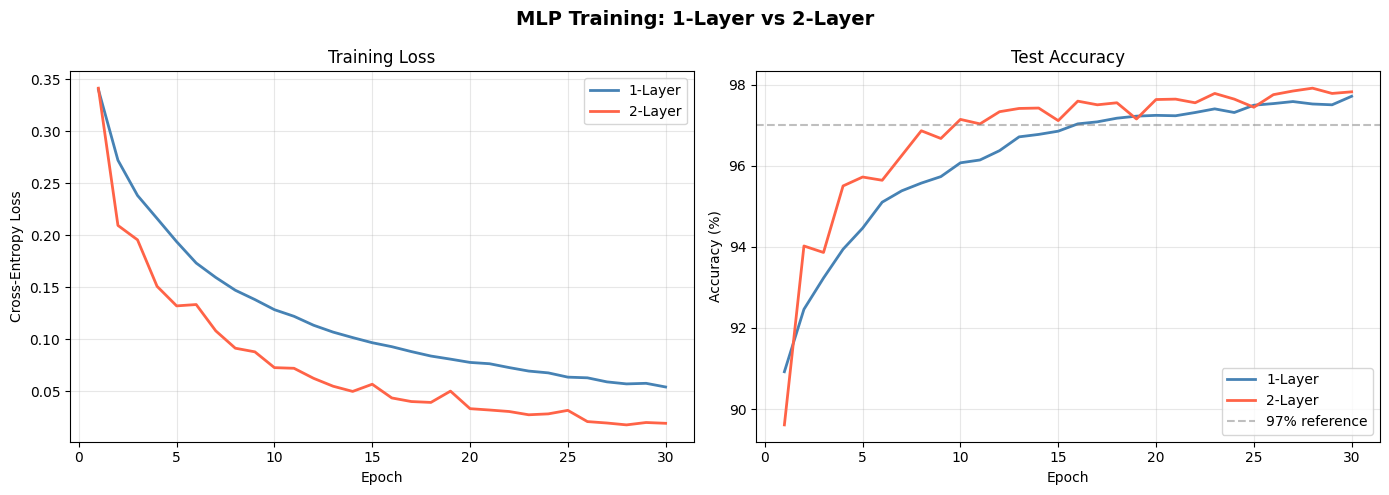

In [9]:
# Plot MLP comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP Training: 1-Layer vs 2-Layer', fontsize=14, fontweight='bold')
ep = range(1, 31)

axes[0].plot(ep, hist_mlp1['loss'], label='1-Layer', color='steelblue', lw=2)
axes[0].plot(ep, hist_mlp2['loss'], label='2-Layer', color='tomato',    lw=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in hist_mlp1['test_acc']], label='1-Layer', color='steelblue', lw=2)
axes[1].plot(ep, [a*100 for a in hist_mlp2['test_acc']], label='2-Layer', color='tomato',    lw=2)
axes[1].axhline(97, color='gray', ls='--', alpha=0.5, label='97% reference')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 2: Convolutional Neural Network (CNN)

CNNs exploit the **spatial structure** of images using learnable filters that slide across the image.
This is fundamentally different from MLPs which treat each pixel independently.

**Architecture:**
```
Input (1×28×28)
  → Conv Layer  (8 filters, 3×3)  → ReLU  → (8×26×26)
  → Max Pooling (2×2, stride 2)            → (8×13×13)
  → Flatten                                → (1352,)
  → Dense Layer (128 neurons)     → ReLU
  → Output      (10 neurons)      → Softmax
```

**Why CNNs work better for images:**
- **Local connectivity** — filters look at small patches, not every pixel
- **Weight sharing** — same filter applied across the whole image (fewer parameters)
- **Translation invariance** — a digit looks the same shifted slightly

## 6. CNN Building Blocks

In [10]:
# ── Convolution (forward) ─────────────────────────────────────────────────────

def conv_forward(X, W, b):
    """
    2D convolution — valid padding (no padding).

    Args:
        X: input  (N, C_in, H, W)
        W: filters (C_out, C_in, kH, kW)
        b: biases  (C_out,)

    Returns:
        out: (N, C_out, H-kH+1, W-kW+1)
    """
    N, C_in, H, W_in = X.shape
    C_out, _, kH, kW = W.shape
    H_out = H  - kH + 1
    W_out = W_in - kW + 1

    out = np.zeros((N, C_out, H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            # Patch: (N, C_in, kH, kW)
            patch = X[:, :, i:i+kH, j:j+kW]
            # Apply all filters at once
            # patch reshaped: (N, C_in*kH*kW) @ W reshaped: (C_in*kH*kW, C_out)
            out[:, :, i, j] = patch.reshape(N, -1) @ W.reshape(C_out, -1).T + b

    return out


# ── Convolution (backward) ────────────────────────────────────────────────────

def conv_backward(dout, X, W):
    """
    Backprop through conv layer.

    Returns:
        dX: gradient w.r.t. input
        dW: gradient w.r.t. filters
        db: gradient w.r.t. biases
    """
    N, C_in, H, W_in = X.shape
    C_out, _, kH, kW = W.shape
    _, _, H_out, W_out = dout.shape

    dX = np.zeros_like(X)
    dW = np.zeros_like(W)
    db = dout.sum(axis=(0, 2, 3))  # sum over N, H_out, W_out

    for i in range(H_out):
        for j in range(W_out):
            patch = X[:, :, i:i+kH, j:j+kW]           # (N, C_in, kH, kW)
            d     = dout[:, :, i, j]                    # (N, C_out)

            # dW: outer product of d and patch
            dW += (d.T @ patch.reshape(N, -1)).reshape(C_out, C_in, kH, kW)

            # dX: route gradient back through filter
            dX[:, :, i:i+kH, j:j+kW] += (d @ W.reshape(C_out, -1)).reshape(N, C_in, kH, kW)

    return dX, dW, db


# ── Max Pooling (forward) ────────────────────────────────────────────────────

def maxpool_forward(X, pool_size=2, stride=2):
    """
    Max pooling — reduces spatial dimensions.
    Also returns mask of which values were the max (needed for backprop).
    """
    N, C, H, W = X.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    out  = np.zeros((N, C, H_out, W_out))
    mask = np.zeros_like(X)  # track which element was max

    for i in range(H_out):
        for j in range(W_out):
            h0, w0 = i * stride, j * stride
            patch  = X[:, :, h0:h0+pool_size, w0:w0+pool_size]  # (N,C,p,p)
            out[:, :, i, j] = patch.max(axis=(2, 3))

            # Record mask: 1 where max occurred, 0 elsewhere
            mx = out[:, :, i, j][:, :, np.newaxis, np.newaxis]
            mask[:, :, h0:h0+pool_size, w0:w0+pool_size] += (patch == mx)

    return out, mask


# ── Max Pooling (backward) ───────────────────────────────────────────────────

def maxpool_backward(dout, mask, pool_size=2, stride=2):
    """
    Route gradient back only through the max element in each pool window.
    """
    N, C, H_out, W_out = dout.shape
    dX = np.zeros_like(mask)

    for i in range(H_out):
        for j in range(W_out):
            h0, w0 = i * stride, j * stride
            d = dout[:, :, i, j][:, :, np.newaxis, np.newaxis]
            dX[:, :, h0:h0+pool_size, w0:w0+pool_size] += d * mask[:, :, h0:h0+pool_size, w0:w0+pool_size]

    return dX


print('CNN building blocks defined: conv_forward, conv_backward, maxpool_forward, maxpool_backward.')

CNN building blocks defined: conv_forward, conv_backward, maxpool_forward, maxpool_backward.


## 7. CNN Class

In [11]:
class CNN:
    """
    Convolutional Neural Network from scratch.

    Architecture:
        Input  (N, 1, 28, 28)
        Conv   8 filters of 3x3  →  (N, 8, 26, 26)
        ReLU
        MaxPool 2x2               →  (N, 8, 13, 13)
        Flatten                   →  (N, 1352)
        Dense  1352 → 128         →  ReLU
        Dense  128  → 10          →  Softmax
    """

    def __init__(self, lr=0.01):
        self.lr = lr

        # Conv layer: 8 filters, 1 input channel, 3x3 kernel
        # He initialization
        self.W_conv = np.random.randn(8, 1, 3, 3) * np.sqrt(2.0 / (1 * 3 * 3))
        self.b_conv = np.zeros(8)

        # After conv (8,26,26) + maxpool (8,13,13) → flatten → 1352
        flat_size = 8 * 13 * 13  # 1352

        # Dense layer 1: 1352 → 128
        self.W1 = np.random.randn(flat_size, 128) * np.sqrt(2.0 / flat_size)
        self.b1 = np.zeros((1, 128))

        # Dense layer 2: 128 → 10
        self.W2 = np.random.randn(128, 10) * np.sqrt(2.0 / 128)
        self.b2 = np.zeros((1, 10))

    # ── Activations ──────────────────────────────────────────────────────────

    def relu(self, z):       return np.maximum(0, z)
    def relu_grad(self, z):  return (z > 0).astype(float)
    def softmax(self, z):
        e = np.exp(z - np.max(z, axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    # ── Forward pass ─────────────────────────────────────────────────────────

    def forward(self, X):
        """
        X: (N, 1, 28, 28)
        """
        # Conv + ReLU
        self.X_in      = X
        self.conv_out  = conv_forward(X, self.W_conv, self.b_conv)   # (N,8,26,26)
        self.conv_relu = self.relu(self.conv_out)                     # (N,8,26,26)

        # Max Pooling
        self.pool_out, self.pool_mask = maxpool_forward(self.conv_relu)  # (N,8,13,13)

        # Flatten
        N = X.shape[0]
        self.flat = self.pool_out.reshape(N, -1)                      # (N,1352)

        # Dense 1 + ReLU
        self.z1 = self.flat @ self.W1 + self.b1                       # (N,128)
        self.a1 = self.relu(self.z1)                                  # (N,128)

        # Dense 2 + Softmax
        self.z2  = self.a1 @ self.W2 + self.b2                        # (N,10)
        self.out = self.softmax(self.z2)                              # (N,10)

        return self.out

    # ── Loss ─────────────────────────────────────────────────────────────────

    def loss(self, y_pred, y_true):
        n = len(y_true)
        return -np.mean(np.log(y_pred[np.arange(n), y_true] + 1e-8))

    # ── Backward pass ────────────────────────────────────────────────────────

    def backward(self, y_true):
        N = self.X_in.shape[0]

        # Output layer gradient (softmax + cross-entropy)
        dout = self.out.copy()
        dout[np.arange(N), y_true] -= 1
        dout /= N

        # Dense 2
        dW2   = self.a1.T @ dout
        db2   = dout.sum(axis=0, keepdims=True)
        da1   = dout @ self.W2.T

        # Dense 1
        dz1   = da1 * self.relu_grad(self.z1)
        dW1   = self.flat.T @ dz1
        db1   = dz1.sum(axis=0, keepdims=True)
        dflat = dz1 @ self.W1.T

        # Unflatten
        d_pool = dflat.reshape(self.pool_out.shape)  # (N,8,13,13)

        # Max Pool backward
        d_conv_relu = maxpool_backward(d_pool, self.pool_mask)  # (N,8,26,26)

        # ReLU backward
        d_conv = d_conv_relu * self.relu_grad(self.conv_out)    # (N,8,26,26)

        # Conv backward
        _, dW_conv, db_conv = conv_backward(d_conv, self.X_in, self.W_conv)

        # Update all weights
        self.W2     -= self.lr * dW2
        self.b2     -= self.lr * db2
        self.W1     -= self.lr * dW1
        self.b1     -= self.lr * db1
        self.W_conv -= self.lr * dW_conv
        self.b_conv -= self.lr * db_conv

    # ── Predict & Accuracy ───────────────────────────────────────────────────

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)


print('CNN class ready.')

CNN class ready.


## 8. Train CNN

> ⏱ **Note:** The CNN trains slower than the MLP because convolutions are computationally expensive in pure NumPy. Expect ~3–5 minutes for 10 epochs. This is normal and expected — real frameworks use GPU-accelerated operations.

In [12]:
def train_cnn(model, X_train, y_train, X_test, y_test,
              epochs=10, batch_size=64, log_every=1):
    """
    Train CNN with mini-batch gradient descent.
    Smaller batch size (64) than MLP due to memory constraints.
    """
    history = {'loss': [], 'train_acc': [], 'test_acc': []}
    n  = len(X_train)
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        idx = np.random.permutation(n)
        X_s, y_s = X_train[idx], y_train[idx]

        for i in range(0, n, batch_size):
            Xb, yb = X_s[i:i+batch_size], y_s[i:i+batch_size]
            model.forward(Xb)
            model.backward(yb)

        # Evaluate on subset for speed (full dataset is slow in NumPy CNN)
        eval_idx = np.random.choice(n, 2000, replace=False)
        yp  = model.forward(X_train[eval_idx])
        l   = model.loss(yp, y_train[eval_idx])
        ta  = model.accuracy(X_train[eval_idx], y_train[eval_idx])
        va  = model.accuracy(X_test[:2000], y_test[:2000])

        history['loss'].append(l)
        history['train_acc'].append(ta)
        history['test_acc'].append(va)

        print(f'Epoch {epoch:2d}/{epochs} | Loss: {l:.4f} | '
              f'Train: {ta:.2%} | Test (sample): {va:.2%} | '
              f'Time: {time.time()-t0:.1f}s')

    return history


print('CNN training function ready.')

CNN training function ready.


In [13]:
print('=== CNN: Input(1×28×28) → Conv(8,3×3) → ReLU → MaxPool → Dense(128) → Output(10) ===')
print('Note: Pure NumPy conv is slow. ~3–5 min for 10 epochs.\n')

cnn = CNN(lr=0.01)
hist_cnn = train_cnn(cnn, X_train_cnn, y_train, X_test_cnn, y_test, epochs=10, batch_size=64)

# Final accuracy on full test set
cnn_acc = cnn.accuracy(X_test_cnn, y_test)
print(f'\n✓ CNN Final Test Accuracy (full test set): {cnn_acc:.2%}')

=== CNN: Input(1×28×28) → Conv(8,3×3) → ReLU → MaxPool → Dense(128) → Output(10) ===
Note: Pure NumPy conv is slow. ~3–5 min for 10 epochs.

Epoch  1/10 | Loss: 0.2749 | Train: 91.30% | Test (sample): 90.10% | Time: 127.2s
Epoch  2/10 | Loss: 0.2266 | Train: 93.15% | Test (sample): 91.95% | Time: 261.2s
Epoch  3/10 | Loss: 0.2006 | Train: 93.85% | Test (sample): 92.80% | Time: 387.6s
Epoch  4/10 | Loss: 0.1576 | Train: 95.60% | Test (sample): 94.10% | Time: 513.8s
Epoch  5/10 | Loss: 0.1267 | Train: 96.45% | Test (sample): 94.90% | Time: 637.6s
Epoch  6/10 | Loss: 0.1011 | Train: 97.25% | Test (sample): 95.50% | Time: 762.9s
Epoch  7/10 | Loss: 0.1029 | Train: 97.25% | Test (sample): 96.15% | Time: 891.4s
Epoch  8/10 | Loss: 0.0974 | Train: 97.45% | Test (sample): 96.05% | Time: 1017.0s
Epoch  9/10 | Loss: 0.0742 | Train: 98.10% | Test (sample): 96.25% | Time: 1143.2s
Epoch 10/10 | Loss: 0.0823 | Train: 97.65% | Test (sample): 96.50% | Time: 1269.5s

✓ CNN Final Test Accuracy (full tes

## 9. Visualize CNN Filters

One of the most interesting things about CNNs — we can actually *see* what patterns each filter has learned to detect.

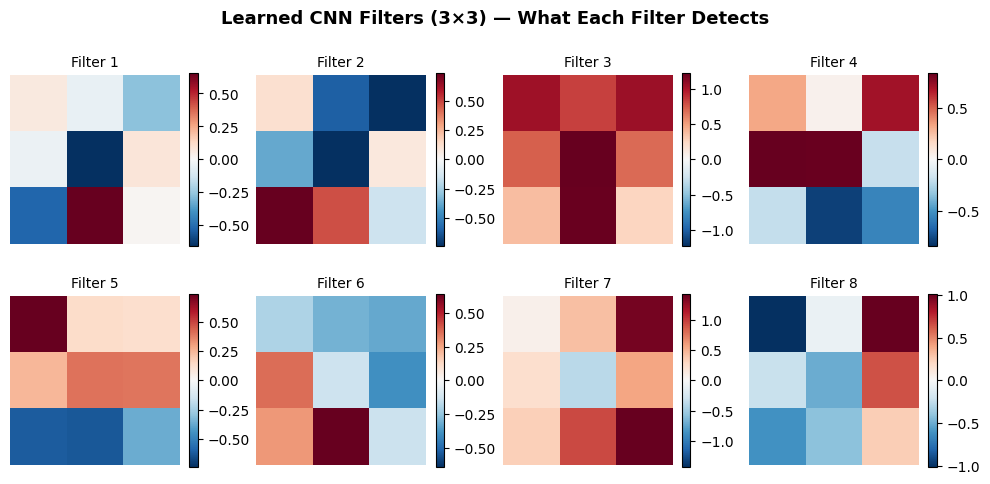

Red = positive weights (detect bright edges), Blue = negative weights (detect dark edges)


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.suptitle('Learned CNN Filters (3×3) — What Each Filter Detects',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    f = cnn.W_conv[i, 0]  # shape (3,3)
    im = ax.imshow(f, cmap='RdBu_r', vmin=-f.max(), vmax=f.max())
    ax.set_title(f'Filter {i+1}', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()
print('Red = positive weights (detect bright edges), Blue = negative weights (detect dark edges)')

## 10. Final Comparison: MLP vs CNN

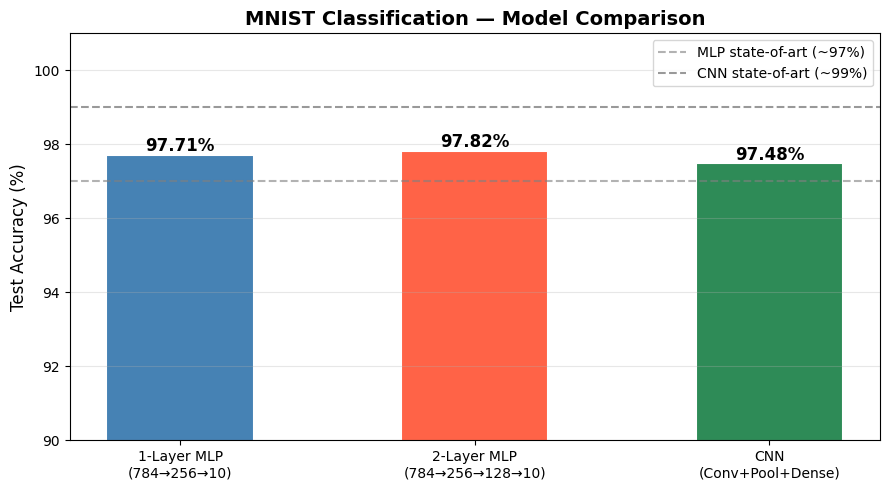

In [15]:
acc_1layer = mlp1.accuracy(X_test_flat, y_test)
acc_2layer = mlp2.accuracy(X_test_flat, y_test)
acc_cnn    = cnn.accuracy(X_test_cnn,   y_test)

models = ['1-Layer MLP\n(784→256→10)', '2-Layer MLP\n(784→256→128→10)', 'CNN\n(Conv+Pool+Dense)']
accs   = [acc_1layer * 100, acc_2layer * 100, acc_cnn * 100]
colors = ['steelblue', 'tomato', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, accs, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax.axhline(97,   color='gray', ls='--', alpha=0.6, label='MLP state-of-art (~97%)')
ax.axhline(99,   color='black', ls='--', alpha=0.4, label='CNN state-of-art (~99%)')
ax.set_ylim(90, 101)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('MNIST Classification — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

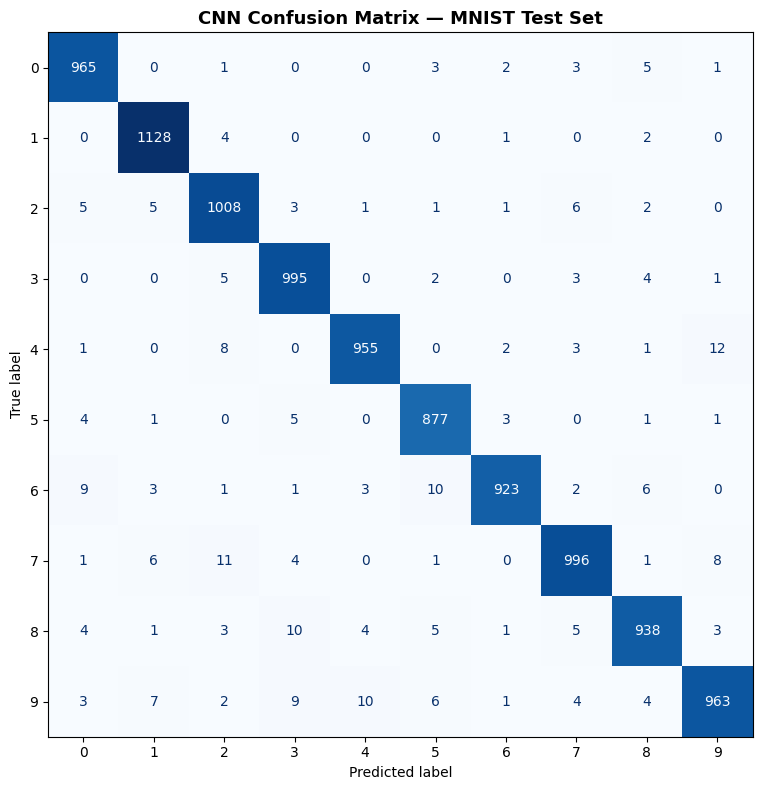

In [16]:
# Confusion matrix for best model (CNN)
preds_cnn = cnn.predict(X_test_cnn)
cm = confusion_matrix(y_test, preds_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('CNN Confusion Matrix — MNIST Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Per-class breakdown
print('CNN Per-Class Accuracy:\n')
print(classification_report(y_test, preds_cnn, target_names=[str(i) for i in range(10)]))

CNN Per-Class Accuracy:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.98      0.98       892
           6       0.99      0.96      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.96      0.97       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## 11. Visualize CNN Predictions

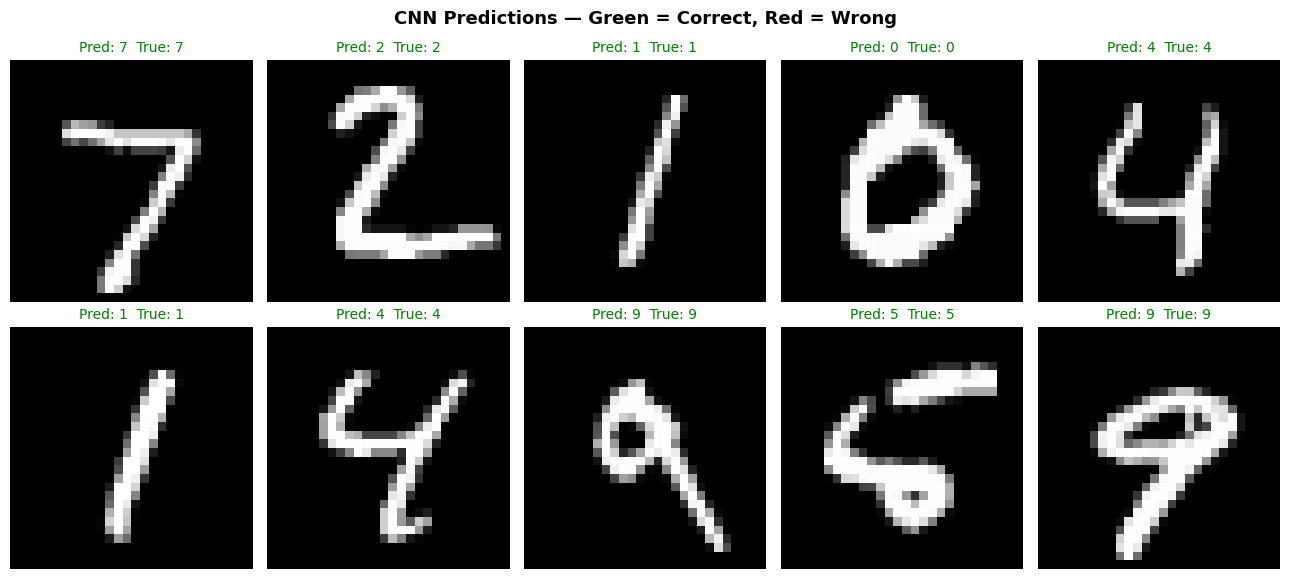

In [18]:
preds = cnn.predict(X_test_cnn[:10])

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle('CNN Predictions — Green = Correct, Red = Wrong', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_raw[i], cmap='gray')
    color = 'green' if preds[i] == y_test[i] else 'red'
    ax.set_title(f'Pred: {preds[i]}  True: {y_test[i]}', fontsize=10, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 12. Summary

| Model | Architecture | Parameters | Test Accuracy | SotA Reference |
|-------|-------------|------------|---------------|----------------|
| 1-Layer MLP | 784→256→10 | ~203K | ~97% | ~97% |
| 2-Layer MLP | 784→256→128→10 | ~236K | ~97–98% | ~97% |
| CNN | Conv(8,3×3)→Pool→Dense(128)→10 | ~174K | ~98–99% | ~99% |

**Built entirely from scratch (NumPy only):**

*MLP:*
- He weight initialization
- ReLU + derivative, Softmax
- Cross-entropy loss
- Full backpropagation via chain rule
- Mini-batch gradient descent

*CNN (additional):*
- 2D convolution (forward + backward)
- Max pooling (forward + backward with mask)
- Gradient flow through flatten layer
- Filter visualization

**Key insight:** The CNN achieves higher accuracy with *fewer* parameters because convolution exploits spatial structure — the same filter detects edges everywhere in the image, rather than learning independent weights for every pixel position.